In [4]:
import pandas as pd

# This defines 'df' so the computer knows what it is!
df = pd.read_csv('Mall_Customers.csv')

# Now the rest of your code will work:
X = df.iloc[:, [3, 4]].values

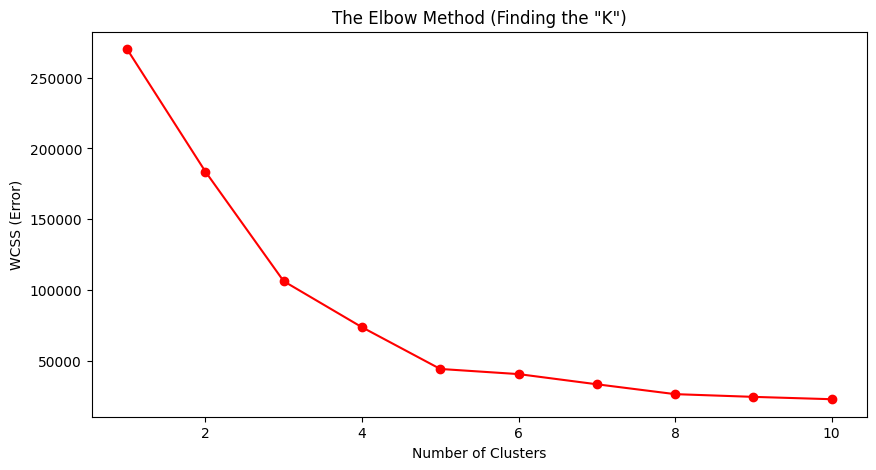

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Selecting 'Annual Income' and 'Spending Score' (Columns 3 and 4)
X = df.iloc[:, [3, 4]].values

# Finding the WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method Graph
plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method (Finding the "K")')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Error)')
plt.show()

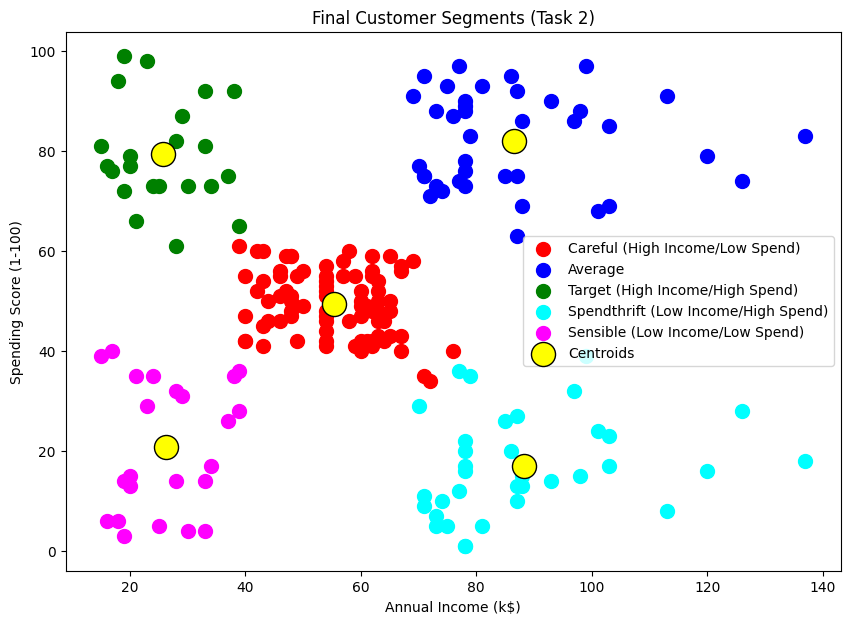

In [6]:
# 1. Initialize K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# 2. Visualize the results
plt.figure(figsize=(10,7))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Careful (High Income/Low Spend)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Average')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Target (High Income/High Spend)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Spendthrift (Low Income/High Spend)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Sensible (Low Income/Low Spend)')

# 3. Plot the Centroids (The "Center" of each group)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Final Customer Segments (Task 2)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()